# Automated Revenue & Profit Monitoring System

## Project Overview

This project builds an automated business reporting workflow for Superstore sales data. The goal is to move beyond basic analysis and create a repeatable monitoring system that can combine monthly sales files, validate data quality, calculate revenue and profitability KPIs, detect business risks, and export final reports for stakeholders.

## Business Problem

Sales teams often receive transaction data in separate monthly files. Manually combining files, checking data quality, calculating KPIs, and preparing reports takes time and can introduce errors. This project automates that workflow and produces consistent monthly performance outputs.

## Tools Used

- Python
- pandas
- matplotlib
- Google Colab

## Key Outputs

- Cleaned combined sales dataset
- Monthly KPI summary
- Data validation summary
- Revenue and profit risk alerts
- Category and region performance summaries
- Visual charts
- Business insight text report


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sample_-_superstore.xls to sample_-_superstore.xls


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "sample_-_superstore.xls"

df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
!pip install xlrd

In [ ]:
df = pd.read_excel("sample_-_superstore.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
required_columns = [
    "Order Date", "Ship Date", "Region", "Category", "Sub-Category",
    "Product Name", "Sales", "Quantity", "Discount", "Profit"
]

for col in required_columns:
    print(col, ":", col in df.columns)

Order Date : True
Ship Date : True
Region : True
Category : True
Sub-Category : True
Product Name : True
Sales : True
Quantity : True
Discount : True
Profit : True


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

Date range:
2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [ ]:
df.shape
df.columns
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## Data Preparation and Monthly File Simulation

After loading and inspecting the dataset, the date fields are converted into proper datetime format. Additional reporting columns such as year, month, month-year, and shipping days are created.

To demonstrate automation, the original dataset is split into multiple monthly CSV files. This simulates a real reporting process where new sales files arrive every month.


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Year"] = df["Order Date"].dt.to_period("M").astype(str)

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Date range:", df["Order Date"].min(), "to", df["Order Date"].max())
print("Shape:", df.shape)

df[["Order Date", "Ship Date", "Year", "Month", "Month_Year", "Shipping Days"]].head()

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Shape: (9994, 25)


,Order Date,Ship Date,Year,Month,Month_Year,Shipping Days
0,2016-11-08,2016-11-11,2016,11,2016-11,3
1,2016-11-08,2016-11-11,2016,11,2016-11,3
2,2016-06-12,2016-06-16,2016,6,2016-06,4
3,2015-10-11,2015-10-18,2015,10,2015-10,7
4,2015-10-11,2015-10-18,2015,10,2015-10,7


### Create Monthly CSV Files

The dataset is grouped by month and exported into separate CSV files. These files represent recurring monthly sales extracts that an analyst might receive from a business system.


In [ ]:
import os

monthly_folder = "monthly_sales_files"
os.makedirs(monthly_folder, exist_ok=True)

for month, month_df in df.groupby("Month_Year"):
    file_name = f"sales_{month}.csv"
    file_path = os.path.join(monthly_folder, file_name)
    month_df.to_csv(file_path, index=False)

print("Monthly CSV files created:", len(os.listdir(monthly_folder)))
os.listdir(monthly_folder)[:5]

Monthly CSV files created: 48


['sales_2017-10.csv',
 'sales_2016-12.csv',
 'sales_2016-02.csv',
 'sales_2017-12.csv',
 'sales_2017-04.csv']

### Combine Monthly Files Automatically

The script reads every CSV file from the monthly folder and combines them into a single dataframe. This removes manual copy-paste work and makes the workflow reusable for future monthly files.


In [ ]:
import glob

csv_files = glob.glob("monthly_sales_files/*.csv")

combined_df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

print("Combined shape:", combined_df.shape)
combined_df.head()

Combined shape: (9994, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Year,Shipping Days
0,35,CA-2017-107727,2017-10-19,2017-10-23,Second Class,MA-17560,Matt Abelman,Home Office,United States,Houston,...,Paper,Easy-staple paper,29.472,3,0.2,9.9468,2017,10,2017-10,4
1,87,CA-2017-155558,2017-10-26,2017-11-02,Standard Class,PG-18895,Paul Gonzalez,Consumer,United States,Rochester,...,Accessories,Logitech LS21 Speaker System - PC Multimedia -...,19.990,1,0.0,6.7966,2017,10,2017-10,7
2,88,CA-2017-155558,2017-10-26,2017-11-02,Standard Class,PG-18895,Paul Gonzalez,Consumer,United States,Rochester,...,Labels,Avery 511,6.160,2,0.0,2.9568,2017,10,2017-10,7
3,277,CA-2017-132976,2017-10-13,2017-10-17,Standard Class,AG-10495,Andrew Gjertsen,Corporate,United States,Philadelphia,...,Paper,"Post-it “Important Message” Note Pad, Neon Col...",11.648,2,0.2,4.0768,2017,10,2017-10,4
4,278,CA-2017-132976,2017-10-13,2017-10-17,Standard Class,AG-10495,Andrew Gjertsen,Corporate,United States,Philadelphia,...,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",18.176,4,0.2,5.9072,2017,10,2017-10,4


## Data Validation Checks

Before calculating KPIs, the pipeline validates whether the dataset is reliable enough for reporting. These checks help catch missing columns, duplicate rows, invalid dates, negative sales values, invalid discounts, and incorrect shipping dates.


In [ ]:
# Convert date columns again after reading combined CSV files
combined_df["Order Date"] = pd.to_datetime(combined_df["Order Date"])
combined_df["Ship Date"] = pd.to_datetime(combined_df["Ship Date"])

# Required columns for this project
required_columns = [
    "Order ID", "Order Date", "Ship Date", "Region", "Category",
    "Sub-Category", "Product Name", "Sales", "Quantity", "Discount", "Profit"
]

validation_results = {}

# 1. Check missing required columns
missing_columns = [col for col in required_columns if col not in combined_df.columns]
validation_results["missing_required_columns"] = missing_columns

# 2. Check missing values
validation_results["missing_values"] = combined_df[required_columns].isnull().sum()

# 3. Check duplicate rows
validation_results["duplicate_rows"] = combined_df.duplicated().sum()

# 4. Check invalid sales/quantity values
validation_results["negative_sales_count"] = (combined_df["Sales"] < 0).sum()
validation_results["zero_or_negative_quantity_count"] = (combined_df["Quantity"] <= 0).sum()

# 5. Check discount outside expected range
validation_results["invalid_discount_count"] = (
    (combined_df["Discount"] < 0) | (combined_df["Discount"] > 1)
).sum()

# 6. Check shipping date before order date
validation_results["invalid_shipping_dates_count"] = (
    combined_df["Ship Date"] < combined_df["Order Date"]
).sum()

validation_results

{'missing_required_columns': [],
 'missing_values': Order ID        0
 Order Date      0
 Ship Date       0
 Region          0
 Category        0
 Sub-Category    0
 Product Name    0
 Sales           0
 Quantity        0
 Discount        0
 Profit          0
 dtype: int64,
 'duplicate_rows': np.int64(0),
 'negative_sales_count': np.int64(0),
 'zero_or_negative_quantity_count': np.int64(0),
 'invalid_discount_count': np.int64(0),
 'invalid_shipping_dates_count': np.int64(0)}

### Validation Summary

The validation results are converted into a readable summary table. This gives stakeholders confidence that the reporting output is based on clean and consistent data.


In [ ]:
validation_summary = pd.DataFrame({
    "Check": [
        "Missing required columns",
        "Duplicate rows",
        "Negative sales records",
        "Zero/negative quantity records",
        "Invalid discount records",
        "Invalid shipping dates"
    ],
    "Result": [
        len(missing_columns),
        validation_results["duplicate_rows"],
        validation_results["negative_sales_count"],
        validation_results["zero_or_negative_quantity_count"],
        validation_results["invalid_discount_count"],
        validation_results["invalid_shipping_dates_count"]
    ]
})

validation_summary

,Check,Result
0,Missing required columns,0
1,Duplicate rows,0
2,Negative sales records,0
3,Zero/negative quantity records,0
4,Invalid discount records,0
5,Invalid shipping dates,0


## KPI Calculation

This section calculates the core business metrics used for revenue and profitability monitoring: total sales, total profit, order count, quantity sold, average order value, profit margin, and average discount.


In [ ]:
# Basic KPI calculations
total_sales = combined_df["Sales"].sum()
total_profit = combined_df["Profit"].sum()
total_orders = combined_df["Order ID"].nunique()
total_quantity = combined_df["Quantity"].sum()
average_order_value = total_sales / total_orders
profit_margin = total_profit / total_sales
average_discount = combined_df["Discount"].mean()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value",
        "Profit Margin",
        "Average Discount"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_quantity,
        average_order_value,
        profit_margin,
        average_discount
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Quantity Sold,3.787300e+04
4,Average Order Value,4.586147e+02
5,Profit Margin,1.246722e-01
6,Average Discount,1.562027e-01


### Monthly KPI Summary

The monthly KPI table tracks performance over time. It includes sales, profit, order volume, quantity, discount, profit margin, average order value, and month-over-month growth rates.


In [ ]:
monthly_kpi = combined_df.groupby("Month_Year").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    total_orders=("Order ID", "nunique"),
    total_quantity=("Quantity", "sum"),
    avg_discount=("Discount", "mean")
).reset_index()

monthly_kpi["profit_margin"] = monthly_kpi["total_profit"] / monthly_kpi["total_sales"]
monthly_kpi["average_order_value"] = monthly_kpi["total_sales"] / monthly_kpi["total_orders"]

monthly_kpi["sales_growth_pct"] = monthly_kpi["total_sales"].pct_change() * 100
monthly_kpi["profit_growth_pct"] = monthly_kpi["total_profit"].pct_change() * 100

monthly_kpi.head()

,Month_Year,total_sales,total_profit,total_orders,total_quantity,avg_discount,profit_margin,average_order_value,sales_growth_pct,profit_growth_pct
0,2014-01,14236.895,2450.1907,32,284,0.126582,0.172101,444.902969,NaN,NaN
1,2014-02,4519.892,862.3084,28,159,0.176087,0.190781,161.424714,-68.252263,-64.806478
2,2014-03,55691.009,498.7299,71,585,0.167516,0.008955,784.380408,1132.131409,-42.163395
3,2014-04,28295.345,3488.8352,66,536,0.110000,0.123301,428.717348,-49.192257,599.544022
4,2014-05,23648.287,2738.7096,69,466,0.155328,0.115810,342.728797,-16.423401,-21.500746


### Review Monthly Performance

The full monthly summary is reviewed to understand trends and prepare for monthly alert detection.


In [ ]:
monthly_kpi

,Month_Year,total_sales,total_profit,total_orders,total_quantity,avg_discount,profit_margin,average_order_value,sales_growth_pct,profit_growth_pct
0,2014-01,14236.8950,2450.1907,32,284,0.126582,0.172101,444.902969,NaN,NaN
1,2014-02,4519.8920,862.3084,28,159,0.176087,0.190781,161.424714,-68.252263,-64.806478
2,2014-03,55691.0090,498.7299,71,585,0.167516,0.008955,784.380408,1132.131409,-42.163395
3,2014-04,28295.3450,3488.8352,66,536,0.110000,0.123301,428.717348,-49.192257,599.544022
4,2014-05,23648.2870,2738.7096,69,466,0.155328,0.115810,342.728797,-16.423401,-21.500746
5,2014-06,34595.1276,4976.5244,66,521,0.172000,0.143850,524.168600,46.290205,81.710554
6,2014-07,33946.3930,-841.4826,65,550,0.171678,-0.024789,522.252200,-1.875220,-116.909042
7,2014-08,27909.4685,5318.1050,72,609,0.131046,0.190548,387.631507,-17.783699,-731.992272
8,2014-09,81777.3508,8328.0994,130,1000,0.159963,0.101839,629.056545,193.009345,56.599003
9,2014-10,31453.3930,3448.2573,78,573,0.160063,0.109631,403.248628,-61.537770,-58.594907


## Business Risk Detection

This is the main value-add section of the project. Instead of only reporting what happened, the notebook applies rule-based logic to flag potential business risks such as high sales with weak profit, loss-making products, high discount losses, and weak category or region margins.


In [ ]:
# Product-level performance
product_perf = combined_df.groupby(["Product Name", "Category", "Sub-Category"]).agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    total_quantity=("Quantity", "sum"),
    avg_discount=("Discount", "mean"),
    total_orders=("Order ID", "nunique")
).reset_index()

product_perf["profit_margin"] = product_perf["total_profit"] / product_perf["total_sales"]

product_perf.head()

,Product Name,Category,Sub-Category,total_sales,total_profit,total_quantity,avg_discount,total_orders,profit_margin
0,"""While you Were Out"" Message Book, One Form pe...",Office Supplies,Paper,25.228,10.3880,8,0.133333,3,0.411765
1,"#10 Gummed Flap White Envelopes, 100/Box",Office Supplies,Envelopes,41.300,16.7678,11,0.100000,4,0.406000
2,#10 Self-Seal White Envelopes,Office Supplies,Envelopes,108.682,52.1230,10,0.050000,4,0.479592
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",Office Supplies,Envelopes,488.904,223.1408,32,0.057143,7,0.456410
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",Office Supplies,Envelopes,286.672,115.2806,37,0.080000,10,0.402134


### Alert 1: High Sales but Low Profit

This alert identifies products with strong revenue but weak profitability. These products may look successful from a sales perspective but may not be contributing enough profit.


In [ ]:
high_sales_threshold = product_perf["total_sales"].quantile(0.75)

high_sales_low_profit = product_perf[
    (product_perf["total_sales"] >= high_sales_threshold) &
    (product_perf["profit_margin"] < 0.05)
].sort_values("total_sales", ascending=False)

high_sales_low_profit.head(10)

,Product Name,Category,Sub-Category,total_sales,total_profit,total_quantity,avg_discount,total_orders,profit_margin
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.4800,-1.811078e+03,6,0.500000,1,-8.000000e-02
786,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.5760,3.979039e-13,39,0.200000,8,1.819357e-17
688,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.5000,7.609800e+02,48,0.522222,9,4.000000e-02
683,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.0680,-1.878166e+03,27,0.450000,6,-1.045455e-01
813,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.3120,-2.620048e+02,11,0.066667,3,-1.538462e-02
985,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.9010,-4.589973e+03,18,0.400000,4,-2.727273e-01
1043,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.2000,-1.299184e+03,22,0.100000,6,-7.800000e-02
1351,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,15610.9656,-6.695448e+02,24,0.234000,5,-4.288939e-02
368,Bretford Rectangular Conference Table Tops,Furniture,Tables,12995.2915,-3.272331e+02,46,0.245833,12,-2.518090e-02
475,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.9630,-8.879970e+03,9,0.533333,3,-8.000000e-01


### Alert 2: Loss-Making Products

This alert lists products where total profit is negative. These items may need pricing review, discount control, supplier review, or removal from priority sales campaigns.


In [ ]:
loss_making_products = product_perf[
    product_perf["total_profit"] < 0
].sort_values("total_profit")

loss_making_products.head(10)

,Product Name,Category,Sub-Category,total_sales,total_profit,total_quantity,avg_discount,total_orders,profit_margin
475,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.963,-8879.9704,9,0.533333,3,-0.800000
985,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.901,-4589.9730,18,0.400000,4,-0.272727
476,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,-3839.9904,4,0.500000,1,-0.480000
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.640,-2876.1156,27,0.280000,5,-0.290000
376,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.725,-1934.3976,33,0.350000,7,-0.202667
683,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1878.1662,27,0.450000,6,-0.104545
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1811.0784,6,0.500000,1,-0.080000
1043,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.200,-1299.1836,22,0.100000,6,-0.078000
285,Balt Solid Wood Round Tables,Furniture,Tables,6518.754,-1201.0581,19,0.200000,4,-0.184247
364,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.250,-1148.4375,15,0.483333,3,-0.673077


### Alert 3: High Discount and Negative Profit

This alert checks whether heavy discounting is linked with products that lose money. It helps identify where discount strategy may be damaging profitability.


In [ ]:
high_discount_loss = product_perf[
    (product_perf["avg_discount"] >= 0.30) &
    (product_perf["total_profit"] < 0)
].sort_values("avg_discount", ascending=False)

high_discount_loss.head(10)

,Product Name,Category,Sub-Category,total_sales,total_profit,total_quantity,avg_discount,total_orders,profit_margin
605,Eureka Disposable Bags for Sanitaire Vibra Gro...,Office Supplies,Appliances,1.624,-4.4660,2,0.800000,1,-2.750000
696,GBC Plasticlear Binding Covers,Office Supplies,Binders,68.880,-68.4208,23,0.728571,7,-0.993333
716,GBC VeloBinder Electric Binding Machine,Office Supplies,Binders,496.018,-411.3320,15,0.725000,4,-0.829268
1215,Okidata B401 Printer,Technology,Machines,179.991,-251.9874,3,0.700000,1,-1.400000
986,Lexmark MarkNet N8150 Wireless Print Server,Technology,Machines,723.510,-506.4570,6,0.700000,2,-0.700000
372,"Brother MFC-9340CDW LED All-In-One Printer, Co...",Technology,Machines,341.991,-319.1916,3,0.700000,1,-0.933333
429,Cisco 8961 IP Phone Charcoal,Technology,Machines,224.937,-164.9538,3,0.700000,1,-0.733333
811,Hewlett-Packard Deskjet F4180 All-in-One Color...,Technology,Machines,101.994,-71.3958,2,0.700000,1,-0.700000
388,"Bush Westfield Collection Bookcases, Dark Cher...",Furniture,Bookcases,90.882,-190.8522,3,0.700000,1,-2.100000
602,Epson Perfection V600 Photo Scanner,Technology,Machines,206.991,-172.4925,3,0.700000,1,-0.833333


### Alert 4: Category-Level Risk

Category-level performance is reviewed to compare sales, profit, average discount, and profit margin across major product groups.


In [ ]:
category_risk = combined_df.groupby("Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_discount=("Discount", "mean"),
    total_quantity=("Quantity", "sum")
).reset_index()

category_risk["profit_margin"] = category_risk["total_profit"] / category_risk["total_sales"]

category_risk.sort_values("profit_margin")

,Category,total_sales,total_profit,avg_discount,total_quantity,profit_margin
0,Furniture,741999.7953,18451.2728,0.173923,8028,0.024867
1,Office Supplies,719047.0320,122490.8008,0.157285,22906,0.170352
2,Technology,836154.0330,145454.9481,0.132323,6939,0.173957


### Alert 5: Region-Level Risk

Region-level performance is reviewed to identify markets with high sales but weaker profitability or unusually high discount levels.


In [ ]:
region_risk = combined_df.groupby("Region").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_discount=("Discount", "mean"),
    total_orders=("Order ID", "nunique")
).reset_index()

region_risk["profit_margin"] = region_risk["total_profit"] / region_risk["total_sales"]

region_risk.sort_values("profit_margin")

,Region,total_sales,total_profit,avg_discount,total_orders,profit_margin
0,Central,501239.8908,39706.3625,0.240353,1175,0.079216
2,South,391721.9050,46749.4303,0.147253,822,0.119343
1,East,678781.2400,91522.7800,0.145365,1401,0.134834
3,West,725457.8245,108418.4489,0.109335,1611,0.149448


**Interview Talking Point**

This project does not stop at descriptive reporting. It uses rule-based alerts to identify products, categories, regions, and months where revenue performance may hide profitability risk.


## Monthly Performance Alerts

This section compares each month with the previous month and flags sharp drops in sales, profit, or profit margin. This is useful for monthly business review meetings and early performance monitoring.


In [ ]:
monthly_alerts = monthly_kpi.copy()

monthly_alerts["margin_change_pct"] = monthly_alerts["profit_margin"].pct_change() * 100

monthly_alerts["sales_alert"] = monthly_alerts["sales_growth_pct"].apply(
    lambda x: "Sales Drop" if x < -10 else "Normal"
)

monthly_alerts["profit_alert"] = monthly_alerts["profit_growth_pct"].apply(
    lambda x: "Profit Drop" if x < -10 else "Normal"
)

monthly_alerts["margin_alert"] = monthly_alerts["margin_change_pct"].apply(
    lambda x: "Margin Drop" if x < -10 else "Normal"
)

monthly_alerts[
    ["Month_Year", "total_sales", "total_profit", "profit_margin",
     "sales_growth_pct", "profit_growth_pct", "margin_change_pct",
     "sales_alert", "profit_alert", "margin_alert"]
].head()

,Month_Year,total_sales,total_profit,profit_margin,sales_growth_pct,profit_growth_pct,margin_change_pct,sales_alert,profit_alert,margin_alert
0,2014-01,14236.895,2450.1907,0.172101,NaN,NaN,NaN,Normal,Normal,Normal
1,2014-02,4519.892,862.3084,0.190781,-68.252263,-64.806478,10.853639,Sales Drop,Profit Drop,Normal
2,2014-03,55691.009,498.7299,0.008955,1132.131409,-42.163395,-95.305971,Normal,Profit Drop,Margin Drop
3,2014-04,28295.345,3488.8352,0.123301,-49.192257,599.544022,1276.845287,Sales Drop,Normal,Normal
4,2014-05,23648.287,2738.7096,0.115810,-16.423401,-21.500746,-6.075080,Sales Drop,Profit Drop,Normal


### Risky Months

Only months with meaningful performance drops are filtered into a separate table so stakeholders can focus on exceptions instead of reviewing every month manually.


In [ ]:
risky_months = monthly_alerts[
    (monthly_alerts["sales_alert"] != "Normal") |
    (monthly_alerts["profit_alert"] != "Normal") |
    (monthly_alerts["margin_alert"] != "Normal")
]

risky_months[
    ["Month_Year", "sales_growth_pct", "profit_growth_pct", "margin_change_pct",
     "sales_alert", "profit_alert", "margin_alert"]
]

,Month_Year,sales_growth_pct,profit_growth_pct,margin_change_pct,sales_alert,profit_alert,margin_alert
1,2014-02,-68.252263,-64.806478,10.853639,Sales Drop,Profit Drop,Normal
2,2014-03,1132.131409,-42.163395,-95.305971,Normal,Profit Drop,Margin Drop
3,2014-04,-49.192257,599.544022,1276.845287,Sales Drop,Normal,Normal
4,2014-05,-16.423401,-21.500746,-6.075080,Sales Drop,Profit Drop,Normal
6,2014-07,-1.875220,-116.909042,-117.232183,Normal,Profit Drop,Margin Drop
7,2014-08,-17.783699,-731.992272,-868.694611,Sales Drop,Profit Drop,Margin Drop
8,2014-09,193.009345,56.599003,-46.554946,Normal,Normal,Margin Drop
9,2014-10,-61.537770,-58.594907,7.651305,Sales Drop,Profit Drop,Normal
11,2014-12,-11.551882,-3.320628,9.306307,Sales Drop,Normal,Normal
12,2015-01,-73.867405,-136.522307,-239.757673,Sales Drop,Profit Drop,Margin Drop


### Alert Summary

The alert summary gives a quick count of detected risk areas across products and months.


In [ ]:
alert_summary = pd.DataFrame({
    "Alert Type": [
        "High sales but low profit products",
        "Loss-making products",
        "High discount loss products",
        "Risky months"
    ],
    "Count": [
        len(high_sales_low_profit),
        len(loss_making_products),
        len(high_discount_loss),
        len(risky_months)
    ]
})

alert_summary

,Alert Type,Count
0,High sales but low profit products,158
1,Loss-making products,301
2,High discount loss products,130
3,Risky months,33


## Data Visualization

The charts below convert the KPI and alert tables into visuals that can be used in a portfolio, presentation, or stakeholder report.


In [ ]:
import os
import matplotlib.pyplot as plt

charts_folder = "charts"
os.makedirs(charts_folder, exist_ok=True)

### Monthly Sales Trend

This line chart shows how total sales changed over time.


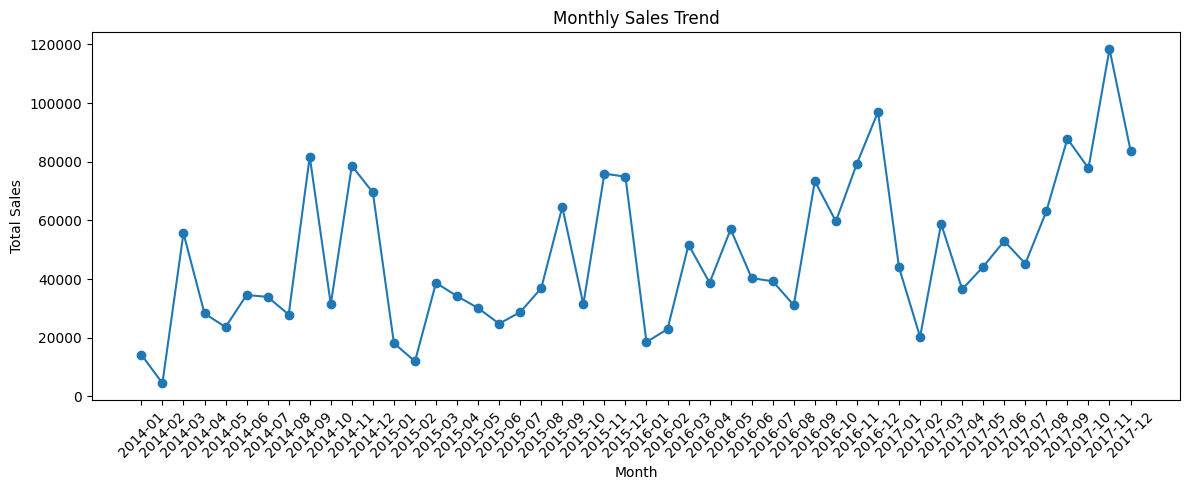

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_kpi["Month_Year"], monthly_kpi["total_sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png", dpi=300)
plt.show()

### Monthly Profit Trend

This line chart shows how total profit changed over time.


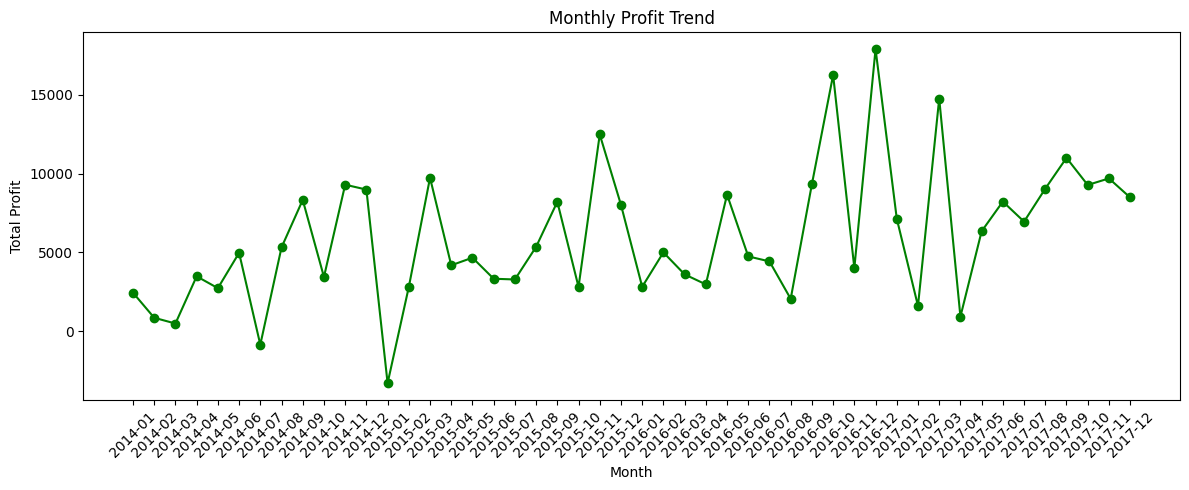

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_kpi["Month_Year"], monthly_kpi["total_profit"], marker="o", color="green")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_profit_trend.png", dpi=300)
plt.show()

### Profit Margin by Category

This chart compares category-level profitability, helping identify which categories are most and least efficient at converting sales into profit.


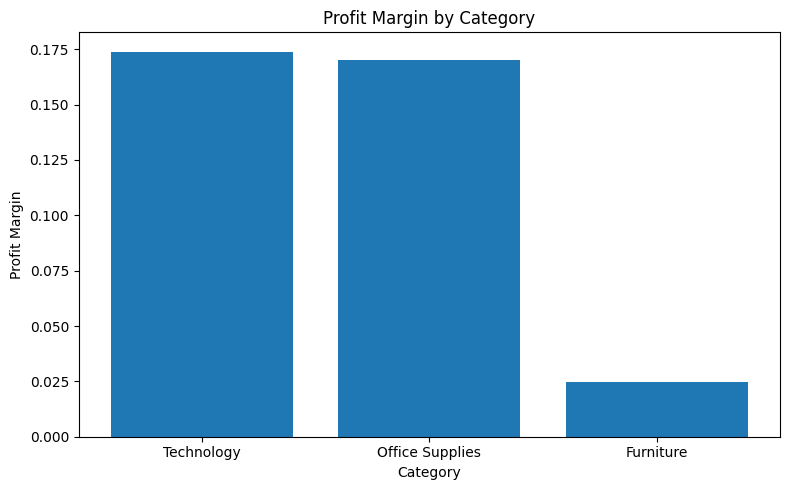

In [ ]:
category_risk_sorted = category_risk.sort_values("profit_margin", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_risk_sorted["Category"], category_risk_sorted["profit_margin"])
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.savefig("charts/profit_margin_by_category.png", dpi=300)
plt.show()

### Sales vs Profit by Region

This chart compares regional revenue with profit to highlight whether high-sales regions are also profitable.


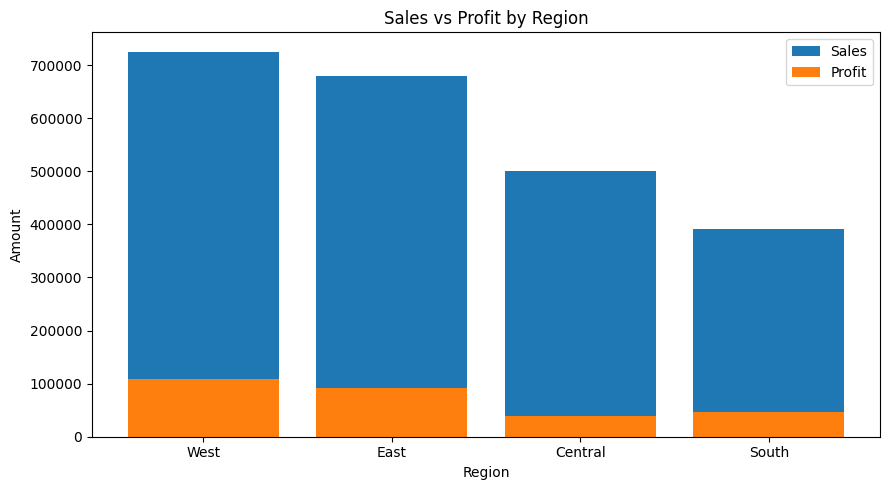

In [ ]:
region_risk_sorted = region_risk.sort_values("total_sales", ascending=False)

x = range(len(region_risk_sorted))

plt.figure(figsize=(9, 5))
plt.bar(x, region_risk_sorted["total_sales"], label="Sales")
plt.bar(x, region_risk_sorted["total_profit"], label="Profit")
plt.xticks(x, region_risk_sorted["Region"])
plt.title("Sales vs Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.savefig("charts/sales_vs_profit_by_region.png", dpi=300)
plt.show()

### Top 10 Loss-Making Products

This chart highlights the products with the largest negative profit contribution.


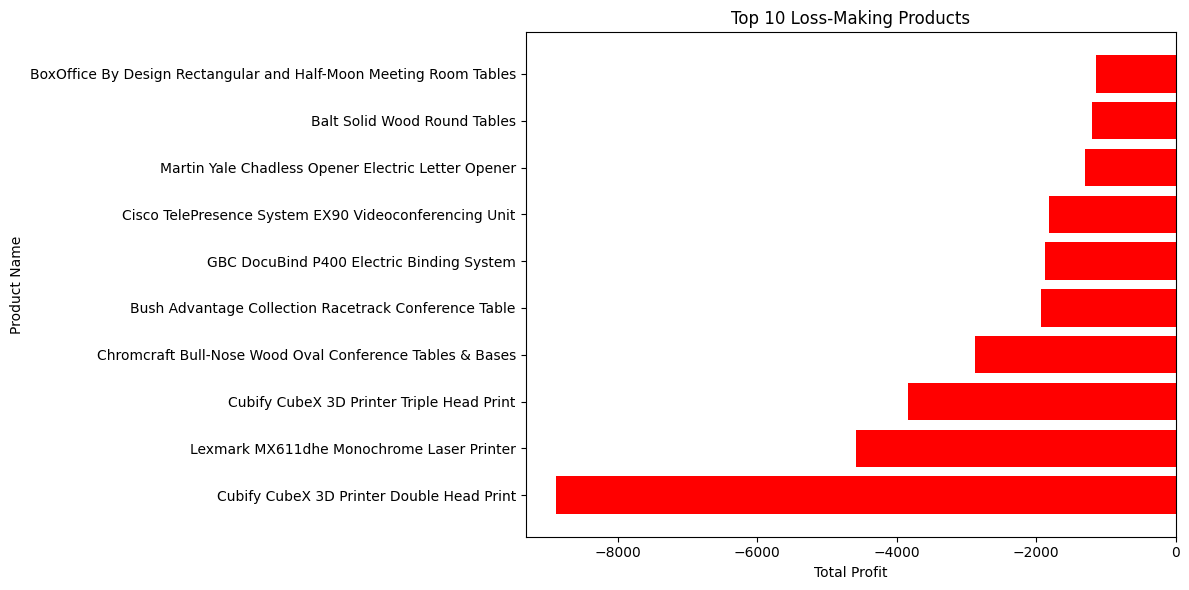

In [ ]:
top_losses = loss_making_products.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_losses["Product Name"], top_losses["total_profit"], color="red")
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.tight_layout()
plt.savefig("charts/top_loss_making_products.png", dpi=300)
plt.show()

### Saved Chart Files

The chart folder is checked to confirm that all visualization files were created successfully.


In [ ]:
os.listdir("charts")

['monthly_sales_trend.png',
 'sales_vs_profit_by_region.png',
 'top_loss_making_products.png',
 'monthly_profit_trend.png',
 'profit_margin_by_category.png']

## Export Final Reports

The final output tables are saved as CSV files. This makes the project usable as a repeatable reporting workflow, not just a one-time notebook analysis.


In [ ]:
output_folder = "output_reports"
os.makedirs(output_folder, exist_ok=True)

### Export KPI and Risk Tables

The cleaned dataset, validation results, KPI summaries, risk tables, and monthly alerts are exported for business review or dashboard use.


In [ ]:
kpi_summary.to_csv("output_reports/kpi_summary.csv", index=False)
monthly_kpi.to_csv("output_reports/monthly_kpi_summary.csv", index=False)
validation_summary.to_csv("output_reports/data_validation_summary.csv", index=False)

high_sales_low_profit.to_csv("output_reports/high_sales_low_profit_products.csv", index=False)
loss_making_products.to_csv("output_reports/loss_making_products.csv", index=False)
high_discount_loss.to_csv("output_reports/high_discount_loss_products.csv", index=False)

category_risk.to_csv("output_reports/category_risk_summary.csv", index=False)
region_risk.to_csv("output_reports/region_risk_summary.csv", index=False)
risky_months.to_csv("output_reports/risky_months.csv", index=False)

combined_df.to_csv("output_reports/cleaned_combined_sales_data.csv", index=False)

### Review Exported Files

The output folder is checked to confirm that all final report files were created successfully.


In [ ]:
os.listdir("output_reports")

['category_risk_summary.csv',
 'region_risk_summary.csv',
 'high_discount_loss_products.csv',
 'cleaned_combined_sales_data.csv',
 'loss_making_products.csv',
 'high_sales_low_profit_products.csv',
 'monthly_kpi_summary.csv',
 'kpi_summary.csv',
 'data_validation_summary.csv',
 'risky_months.csv']

### Combined Business Risk Alert File

A single alert file is created by combining the most important product-level and month-level risks. This gives stakeholders one focused exception report.


In [ ]:
alerts = []

for _, row in high_sales_low_profit.head(10).iterrows():
    alerts.append({
        "Alert Type": "High Sales Low Profit",
        "Entity": row["Product Name"],
        "Category": row["Category"],
        "Sales": row["total_sales"],
        "Profit": row["total_profit"],
        "Profit Margin": row["profit_margin"],
        "Reason": "Product has high sales but weak profit margin"
    })

for _, row in loss_making_products.head(10).iterrows():
    alerts.append({
        "Alert Type": "Loss Making Product",
        "Entity": row["Product Name"],
        "Category": row["Category"],
        "Sales": row["total_sales"],
        "Profit": row["total_profit"],
        "Profit Margin": row["profit_margin"],
        "Reason": "Product generated negative profit"
    })

for _, row in risky_months.iterrows():
    alerts.append({
        "Alert Type": "Monthly Performance Risk",
        "Entity": row["Month_Year"],
        "Category": "Overall Business",
        "Sales": row["total_sales"],
        "Profit": row["total_profit"],
        "Profit Margin": row["profit_margin"],
        "Reason": f"{row['sales_alert']}, {row['profit_alert']}, {row['margin_alert']}"
    })

alerts_df = pd.DataFrame(alerts)

alerts_df.to_csv("output_reports/business_risk_alerts.csv", index=False)

alerts_df.head()

,Alert Type,Entity,Category,Sales,Profit,Profit Margin,Reason
0,High Sales Low Profit,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1.811078e+03,-8.000000e-02,Product has high sales but weak profit margin
1,High Sales Low Profit,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.576,3.979039e-13,1.819357e-17,Product has high sales but weak profit margin
2,High Sales Low Profit,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.500,7.609800e+02,4.000000e-02,Product has high sales but weak profit margin
3,High Sales Low Profit,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.068,-1.878166e+03,-1.045455e-01,Product has high sales but weak profit margin
4,High Sales Low Profit,High Speed Automatic Electric Letter Opener,Office Supplies,17030.312,-2.620048e+02,-1.538462e-02,Product has high sales but weak profit margin


## Automated Business Insights

This section converts the analysis outputs into plain-language insights. These insights can be used in the project README, resume discussion, or interview explanation.


In [ ]:
# Best and worst months
best_sales_month = monthly_kpi.loc[monthly_kpi["total_sales"].idxmax()]
worst_sales_month = monthly_kpi.loc[monthly_kpi["total_sales"].idxmin()]

best_profit_month = monthly_kpi.loc[monthly_kpi["total_profit"].idxmax()]
worst_profit_month = monthly_kpi.loc[monthly_kpi["total_profit"].idxmin()]

# Best and weakest categories
best_category_sales = category_risk.loc[category_risk["total_sales"].idxmax()]
weakest_category_margin = category_risk.loc[category_risk["profit_margin"].idxmin()]

# Best and weakest regions
best_region_sales = region_risk.loc[region_risk["total_sales"].idxmax()]
weakest_region_margin = region_risk.loc[region_risk["profit_margin"].idxmin()]

# Discount impact
avg_discount_loss_products = loss_making_products["avg_discount"].mean()
avg_discount_profitable_products = product_perf[product_perf["total_profit"] > 0]["avg_discount"].mean()

insights = [
    f"Highest sales month was {best_sales_month['Month_Year']} with total sales of {best_sales_month['total_sales']:.2f}.",
    f"Lowest sales month was {worst_sales_month['Month_Year']} with total sales of {worst_sales_month['total_sales']:.2f}.",
    f"Highest profit month was {best_profit_month['Month_Year']} with total profit of {best_profit_month['total_profit']:.2f}.",
    f"Lowest profit month was {worst_profit_month['Month_Year']} with total profit of {worst_profit_month['total_profit']:.2f}.",
    f"{best_category_sales['Category']} generated the highest sales among categories.",
    f"{weakest_category_margin['Category']} had the weakest profit margin among categories.",
    f"{best_region_sales['Region']} generated the highest sales among regions.",
    f"{weakest_region_margin['Region']} had the weakest profit margin among regions.",
    f"Loss-making products had an average discount of {avg_discount_loss_products:.2%}, compared with {avg_discount_profitable_products:.2%} for profitable products.",
    f"The monitoring system detected {len(risky_months)} risky months and {len(loss_making_products)} loss-making products."
]

for insight in insights:
    print("-", insight)

- Highest sales month was 2017-11 with total sales of 118447.82.
- Lowest sales month was 2014-02 with total sales of 4519.89.
- Highest profit month was 2016-12 with total profit of 17885.31.
- Lowest profit month was 2015-01 with total profit of -3281.01.
- Technology generated the highest sales among categories.
- Furniture had the weakest profit margin among categories.
- West generated the highest sales among regions.
- Central had the weakest profit margin among regions.
- Loss-making products had an average discount of 29.14%, compared with 12.44% for profitable products.
- The monitoring system detected 33 risky months and 301 loss-making products.


### Save Business Insights

The generated business insights are saved as a text file so they can be shared with the exported reports.


In [ ]:
with open("output_reports/business_insights.txt", "w") as file:
    for insight in insights:
        file.write("- " + insight + "\n")

### Review Insight Report

The final insight report is printed to confirm that the automated summary was generated correctly.


In [ ]:
with open("output_reports/business_insights.txt", "r") as file:
    print(file.read())

- Highest sales month was 2017-11 with total sales of 118447.82.
- Lowest sales month was 2014-02 with total sales of 4519.89.
- Highest profit month was 2016-12 with total profit of 17885.31.
- Lowest profit month was 2015-01 with total profit of -3281.01.
- Technology generated the highest sales among categories.
- Furniture had the weakest profit margin among categories.
- West generated the highest sales among regions.
- Central had the weakest profit margin among regions.
- Loss-making products had an average discount of 29.14%, compared with 12.44% for profitable products.
- The monitoring system detected 33 risky months and 301 loss-making products.



## Conclusion

This notebook demonstrates an end-to-end automated reporting workflow for revenue and profit monitoring. It combines monthly files, validates data quality, calculates business KPIs, detects performance risks, creates visual reports, and exports stakeholder-ready outputs.

The project is designed to show practical data analyst skills: automation, data cleaning, KPI reporting, profitability analysis, exception reporting, and business communication.
